<a href="https://colab.research.google.com/github/Guhman97/PythonProjectNVB-MH/blob/main/Capstone_Matthew_HennessyFINAL-ITERATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
#Stating the title variables with f strings
MY_DATASET    = "nvb_college_stem_outcomes.csv"
MY_QUESTION   = "\n 1. Do students with internships have higher GPAs and better employment outcomes? \n 2. Which major has the highest on-time graduation rate? \n 3. How does GPA vary across year groups (Freshman to Senior)?"
MY_DOMAIN     = "College stem outcomes"

print(f"Dataset:  {MY_DATASET}")
print(f"Domain:   {MY_DOMAIN}")
print(f"Questions: {MY_QUESTION}")

Dataset:  nvb_college_stem_outcomes.csv
Domain:   College stem outcomes
Questions: 
 1. Do students with internships have higher GPAs and better employment outcomes? 
 2. Which major has the highest on-time graduation rate? 
 3. How does GPA vary across year groups (Freshman to Senior)?


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
url = 'https://drive.google.com/uc?id=15NZhY30mK1ysQhTWatWv87oahSfOtq9y'
df = pd.read_csv(url)
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
#imports and downloads, pandas intialization

Loaded: 300 rows, 12 columns


In [58]:
#SCOUTING
#printed a rundown of data to figure out what variables I would compare
print(f"Shape: {df.shape}")
print()
#dimensions of list type
print("Column types:")
print(df.dtypes)
print()
#vars
print("First 10 rows:")
print(df.head(10))
print()
#for idea of data
print("Basic statistics:")
print(df.describe().round(2))
#gives mean iqr standard deviation and other things that help judge what
#the general values are

Shape: (300, 12)

Column types:
student_id               object
university               object
major                    object
year                     object
credits_completed       float64
cumulative_gpa          float64
internship_completed      int64
research_experience       int64
clubs_count               int64
scholarship               int64
employment_status        object
graduated_on_time       float64
dtype: object

First 10 rows:
  student_id                  university                   major       year  \
0       C001  Tennessee State University    Chemical Engineering     Senior   
1       C002             Spelman College  Electrical Engineering     Junior   
2       C003             Spelman College   Aerospace Engineering     Senior   
3       C004            Prairie View A&M   Aerospace Engineering   Freshman   
4       C005               Virginia Tech    Chemical Engineering  Sophomore   
5       C006            Prairie View A&M  Biomedical Engineering     Senior   
6

In [59]:
#DATA EXPLORATION
# Do students with internships have higher GPAs and better employment outcomes?:
#nullchecked since most nulls indicate still being in school and were valid info
print("Missing values per column:")
print(df.isnull().sum()) # summaryu of nulls
print(f"Total missing: {df.isnull().sum().sum()}") # total nulls
print()

# Got the total of all employed students to better pick my ranges later
print("Print of total non-jobless non-bums")
print((df['employment_status'] == "Employed").sum()) #String checker for total employed students
print("Print total of internships:")
print(df.internship_completed.sum()) #printed total completed to compare to employed later
print()
# Which major has the highest on-time graduation rate?:
print("Print total of graduates:")
print(df.graduated_on_time.sum())
print()
#Got an idea of total grads

# How does GPA vary across year groups:
print("Print average GPA:")
print(f"{(df.cumulative_gpa.sum())/len(df.cumulative_gpa):.2f}") #Sum/total elements down to 2 decimals
print()
#Got the average GPA to judge ranges again

Missing values per column:
student_id                0
university                0
major                     0
year                      0
credits_completed         4
cumulative_gpa            6
internship_completed      0
research_experience       0
clubs_count               0
scholarship               0
employment_status         6
graduated_on_time       212
dtype: int64
Total missing: 228

Print of total non-jobless non-bums
65
Print total of internships:
124

Print total of graduates:
80.0

Print average GPA:
2.95



In [60]:
#Q1 FILTERING - FILTERING BEGIN
#\n 1. Do students with internships have higher GPAs and better employment outcomes?
#\n 2. Which major has the highest on-time graduation rate?
#\n 3. How does GPA vary across year groups (Freshman to Senior)?"
df.groupby('employment_status')['internship_completed'].value_counts().unstack(fill_value=0) #searched up
#groups by the amounts of stuff and counts nulls as zero

# Groupby — multiple aggregations
display(df.groupby('employment_status').agg(avg_val  = ('internship_completed', 'mean'),
    count    = ('internship_completed', 'count'),
))
#Testing this function, kinda useless tho since the mean is one
# Filter — keep rows matching a condition
print("students who completed internship")
display(df[df['internship_completed'] == 1])
print("students who completed internship")
display(df[df['internship_completed'] == 0])
print("students who did both ")
display(df[(df['internship_completed'] == 1) & (df['employment_status'] == 1)])
#Filtered students who got interships and studnets who got j*bs and then showed the ones who had both

,avg_val,count
employment_status,,
Employed,0.615385,65
Grad School,0.812500,16
Not applicable,0.315534,206
Not seeking,0.400000,5
Searching,1.000000,2


students who completed internship


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time
0,C001,Tennessee State University,Chemical Engineering,Senior,117.0,3.65,1,0,4,0,Employed,1.0
1,C002,Spelman College,Electrical Engineering,Junior,88.0,2.88,1,0,3,0,Not applicable,NaN
2,C003,Spelman College,Aerospace Engineering,Senior,129.0,3.32,1,1,3,0,Employed,1.0
5,C006,Prairie View A&M,Biomedical Engineering,Senior,130.0,3.41,1,0,3,0,Grad School,1.0
10,C011,Prairie View A&M,Electrical Engineering,Senior,103.0,2.28,1,0,3,0,Employed,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
287,C288,Prairie View A&M,Data Science,Senior,117.0,2.73,1,1,3,0,Searching,1.0
288,C289,Prairie View A&M,Chemical Engineering,Senior,125.0,3.30,1,1,3,0,Employed,1.0
291,C292,Spelman College,Civil Engineering,Sophomore,54.0,2.54,1,0,3,0,Not applicable,NaN
296,C297,Prairie View A&M,Electrical Engineering,Senior,110.0,3.27,1,1,3,0,Employed,1.0


students who completed internship


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time
3,C004,Prairie View A&M,Aerospace Engineering,Freshman,40.0,3.00,0,0,4,0,Not applicable,NaN
4,C005,Virginia Tech,Chemical Engineering,Sophomore,73.0,2.88,0,0,4,0,Not applicable,NaN
6,C007,North Carolina A&T,Mechanical Engineering,Junior,83.0,3.23,0,0,3,0,NaN,NaN
7,C008,Prairie View A&M,Data Science,Senior,129.0,2.66,0,0,1,0,Employed,0.0
8,C009,Prairie View A&M,Aerospace Engineering,Junior,88.0,3.47,0,0,3,0,Not applicable,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
293,C294,Morgan State University,Mechanical Engineering,Senior,113.0,3.10,0,0,3,0,Employed,1.0
294,C295,Morgan State University,Mechanical Engineering,Sophomore,60.0,2.46,0,0,1,0,Not applicable,NaN
295,C296,Spelman College,Biomedical Engineering,Junior,97.0,3.18,0,1,2,0,Not applicable,NaN
298,C299,North Carolina A&T,Civil Engineering,Freshman,39.0,2.94,0,0,1,0,Not applicable,NaN


students who did both 


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time


In [61]:
#\n 3. How does GPA vary across year groups (Freshman to Senior)?"
df.groupby('year')['cumulative_gpa'].value_counts().unstack(fill_value=0) #searched up
# Groupby grouped totals for each group



# Filter — displayed students of various years who had above a 3.0
print("students with 3.0")
print("Seniors with a 3.0")
display(df[(df['year'] == "Senior") & (df['cumulative_gpa'] >= 3.0)])
print("Juniors with 3.0")
display(df[(df['year'] == "Junior") & (df['cumulative_gpa'] >= 3.0)])
print("Sophomores with 3.0")
display(df[(df['year'] == "Sophomore") & (df['cumulative_gpa'] >= 3.0)])
print("Freshman with 3.0")
display(df[(df['year'] == "Freshman") & (df['cumulative_gpa'] >= 3.0)])

students with 3.0
Seniors with a 3.0


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time
0,C001,Tennessee State University,Chemical Engineering,Senior,117.0,3.65,1,0,4,0,Employed,1.0
2,C003,Spelman College,Aerospace Engineering,Senior,129.0,3.32,1,1,3,0,Employed,1.0
5,C006,Prairie View A&M,Biomedical Engineering,Senior,130.0,3.41,1,0,3,0,Grad School,1.0
15,C016,Tennessee State University,Computer Science,Senior,113.0,3.29,1,1,3,0,Employed,1.0
33,C034,Prairie View A&M,Data Science,Senior,130.0,3.30,0,0,2,0,Not seeking,1.0
39,C040,North Carolina A&T,Chemical Engineering,Senior,130.0,3.24,1,1,3,0,Employed,1.0
49,C050,Spelman College,Biomedical Engineering,Senior,115.0,3.56,1,0,2,1,Grad School,1.0
52,C053,Spelman College,Computer Science,Senior,122.0,3.22,1,0,0,0,Grad School,1.0
64,C065,Florida A&M University,Computer Science,Senior,128.0,3.31,1,1,3,0,Grad School,1.0
67,C068,Florida A&M University,Computer Science,Senior,114.0,3.08,0,0,2,0,Employed,1.0


Juniors with 3.0


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time
6,C007,North Carolina A&T,Mechanical Engineering,Junior,83.0,3.23,0,0,3,0,NaN,NaN
8,C009,Prairie View A&M,Aerospace Engineering,Junior,88.0,3.47,0,0,3,0,Not applicable,NaN
9,C010,Prairie View A&M,Aerospace Engineering,Junior,89.0,3.09,0,1,1,0,Not applicable,NaN
12,C013,Prairie View A&M,Biomedical Engineering,Junior,102.0,3.87,0,0,2,1,Not applicable,NaN
29,C030,Tennessee State University,Mechanical Engineering,Junior,75.0,3.11,1,0,4,0,Not applicable,NaN
30,C031,Howard University,Biomedical Engineering,Junior,86.0,3.44,0,0,4,0,Not applicable,NaN
32,C033,Tennessee State University,Aerospace Engineering,Junior,106.0,3.84,1,0,5,1,Not applicable,NaN
35,C036,Tennessee State University,Computer Science,Junior,90.0,3.12,1,1,2,0,Not applicable,NaN
44,C045,North Carolina A&T,Civil Engineering,Junior,95.0,3.26,1,1,3,0,Not applicable,NaN
80,C081,Howard University,Data Science,Junior,87.0,3.43,1,1,2,0,Not applicable,NaN


Sophomores with 3.0


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time
16,C017,Virginia Tech,Mechanical Engineering,Sophomore,61.0,3.44,0,1,3,0,Not applicable,NaN
19,C020,Howard University,Chemical Engineering,Sophomore,53.0,3.67,0,0,2,1,Not applicable,NaN
20,C021,North Carolina A&T,Biomedical Engineering,Sophomore,61.0,4.00,1,0,3,0,Not applicable,NaN
21,C022,Florida A&M University,Civil Engineering,Sophomore,66.0,3.51,0,1,0,0,Not applicable,NaN
37,C038,Tennessee State University,Chemical Engineering,Sophomore,60.0,3.13,0,0,0,0,Not applicable,NaN
40,C041,Virginia Tech,Chemical Engineering,Sophomore,69.0,3.07,1,0,2,0,Not applicable,NaN
41,C042,Spelman College,Biomedical Engineering,Sophomore,59.0,3.01,0,0,2,0,Not applicable,NaN
42,C043,Virginia Tech,Biomedical Engineering,Sophomore,58.0,3.06,1,1,2,0,Not applicable,NaN
46,C047,Spelman College,Aerospace Engineering,Sophomore,50.0,3.42,0,0,2,0,Not applicable,NaN
60,C061,Prairie View A&M,Mechanical Engineering,Sophomore,63.0,3.77,0,0,3,1,Not applicable,NaN


Freshman with 3.0


,student_id,university,major,year,credits_completed,cumulative_gpa,internship_completed,research_experience,clubs_count,scholarship,employment_status,graduated_on_time
3,C004,Prairie View A&M,Aerospace Engineering,Freshman,40.0,3.00,0,0,4,0,Not applicable,NaN
61,C062,North Carolina A&T,Mechanical Engineering,Freshman,24.0,3.33,0,0,2,0,Not applicable,NaN
88,C089,Morgan State University,Computer Science,Freshman,24.0,3.39,0,0,3,0,Not applicable,NaN
93,C094,Florida A&M University,Data Science,Freshman,36.0,3.62,1,0,1,0,Not applicable,NaN
105,C106,Florida A&M University,Mechanical Engineering,Freshman,33.0,3.52,0,0,2,1,Not applicable,NaN
107,C108,Morgan State University,Biomedical Engineering,Freshman,29.0,3.12,0,0,4,0,Not applicable,NaN
110,C111,North Carolina A&T,Chemical Engineering,Freshman,34.0,3.37,0,0,2,0,Not applicable,NaN
127,C128,Howard University,Biomedical Engineering,Freshman,24.0,3.33,0,0,5,0,Not applicable,NaN
132,C133,Florida A&M University,Data Science,Freshman,41.0,3.25,0,0,4,0,Not applicable,NaN
137,C138,Tennessee State University,Mechanical Engineering,Freshman,21.0,3.18,1,1,1,0,Not applicable,NaN


In [62]:
#\n 2. Which major has the highest on-time graduation rate?
df.groupby('major')['graduated_on_time'].value_counts().unstack(fill_value=0)
#this one seemed simple so only used one command


graduated_on_time,0.0,1.0
major,,
Aerospace Engineering,1,11
Biomedical Engineering,1,13
Chemical Engineering,1,13
Civil Engineering,1,11
Computer Science,0,11
Data Science,2,8
Electrical Engineering,1,6
Mechanical Engineering,1,7


In [63]:

df.groupby('employment_status')['internship_completed'].mean().sort_values(ascending=False)
#Grouped by job status and average internships completed
# Finding 1: Everyone who did and internship is geeking for a job, but only about half of them are employed

,internship_completed
employment_status,
Searching,1.000000
Grad School,0.812500
Employed,0.615385
Not seeking,0.400000
Not applicable,0.315534


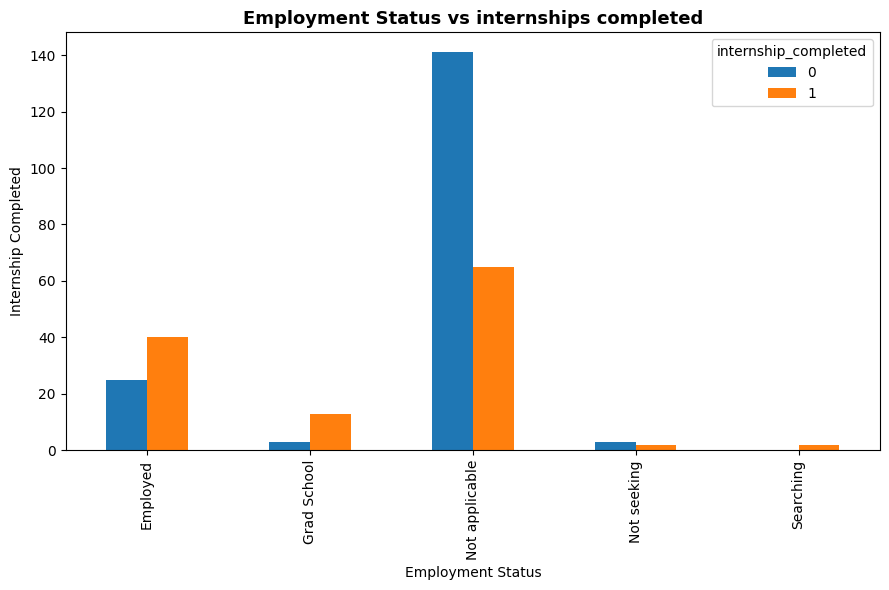

Finding: interships are not the end all say all, alot of people with none still got hired 
 they do bolster your chances quite a bit though


In [64]:
#VISUALIZATION BEGIN

plot_data = df.groupby(['employment_status', 'internship_completed']).size().unstack(fill_value=0)
#grouped and plotted, no nulls of course 0, vs 1s j*bs havers vs happy and then internships
ax = plot_data.plot(kind='bar', figsize=(9, 6))
#graph style bar graph
plt.title("Employment Status vs internships completed", fontsize=13, fontweight="bold")
#labels
plt.xlabel("Employment Status")
plt.ylabel("Internship Completed")
#layout style
plt.tight_layout()
plt.show()
print("Finding: interships are not the end all say all, alot of people with none still got hired \n they do bolster your chances quite a bit though")


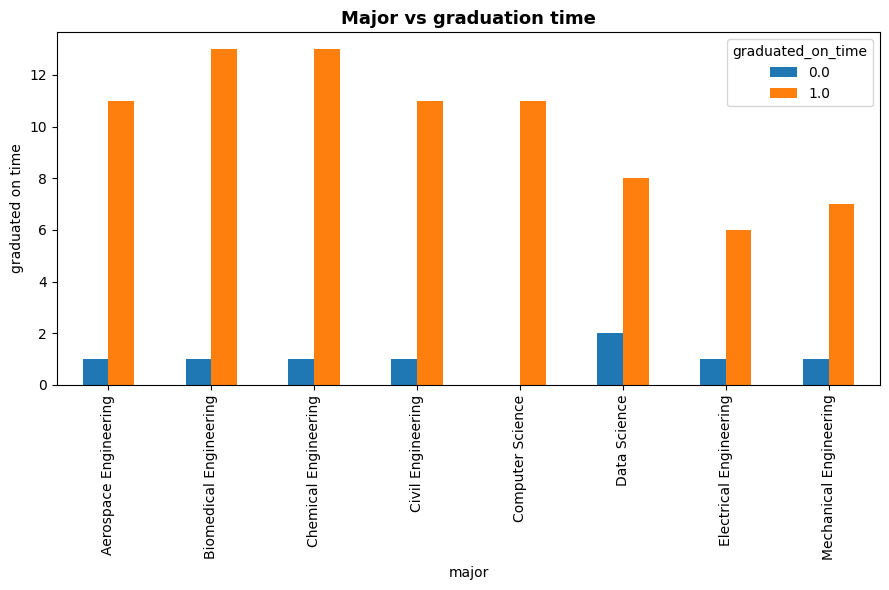

Finding: EEs and Mechies are in the slammer for more time then usual almost twice as much as chem or bio


In [65]:
#\n 2. Which major has the highest on-time graduation rate?
#second verse same as the first only 0, 1 is in school vs done with it
plot_data = df.groupby(['major', 'graduated_on_time']).size().unstack(fill_value=0)
ax = plot_data.plot(kind='bar', figsize=(9, 6))
plt.title("Major vs graduation time", fontsize=13, fontweight="bold")
plt.xlabel("major")
plt.ylabel("graduated on time")
plt.tight_layout()
plt.show()
print("Finding: EEs and Mechies are in the slammer for more time then usual almost twice as much as chem or bio")


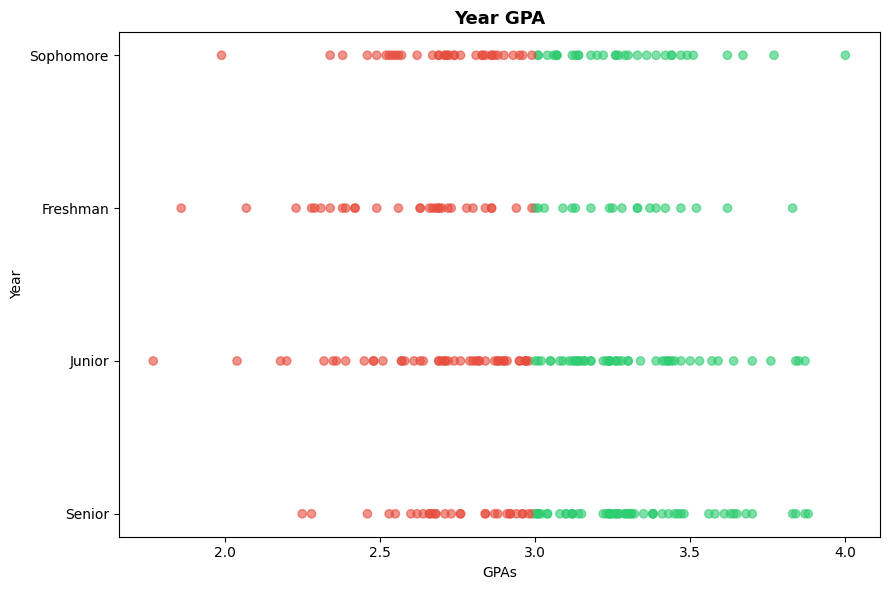

Finding: Sophomores have the greatest performer, 
freshman have the worst, 
juniors are pretty well split with the worst outliers, 
seniors have the most greater then 3 gpas
Sophomores with > 3.0
32
Sophomores with < 3.0
35

Freshies with > 3.0
19
Freshies with < 3.0
31

Junior with > 3.0
49
Junior with < 3.0
46

Senior with > 3.0
55
Senior with < 3.0
30



In [66]:
#\n 3. How does GPA vary across year groups (Freshman to Senior)?"

#Color maker function for graph
#If its 3.0 or above its green if not its red
colors_pass = ["#2ecc71" if p >= 3.0 else "#e74c3c" for p in df["cumulative_gpa"]]

#Plots the data and calls the color function
plt.figure(figsize=(9, 6))
plt.scatter(df['cumulative_gpa'], df['year'],
            c=colors_pass, alpha=0.6)
plt.title("Year GPA", fontsize=13, fontweight="bold")
#labels
plt.xlabel("GPAs")
plt.ylabel("Year")
plt.tight_layout()
plt.show()
print("Finding: Sophomores have the greatest performer, \nfreshman have the worst, \njuniors are pretty well split with the worst outliers, \nseniors have the most greater then 3 gpas")
#this mess was mostly for the final analysis, just tells the total amount of students who fit the bill
#3.0 or below 3.0 and a certain year F, S, J, SS
print("Sophomores with > 3.0")
print(((df['cumulative_gpa'] >= 3.0) & (df['year'] == "Sophomore")).sum())
print("Sophomores with < 3.0")
print(((df['cumulative_gpa'] <= 3.0) & (df['year'] == "Sophomore")).sum())
print()
print("Freshies with > 3.0")
print(((df['cumulative_gpa'] >= 3.0) & (df['year'] == "Freshman")).sum())
print("Freshies with < 3.0")
print(((df['cumulative_gpa'] <= 3.0) & (df['year'] == "Freshman")).sum())
print()
print("Junior with > 3.0")
print(((df['cumulative_gpa'] >= 3.0) & (df['year'] == "Junior")).sum())
print("Junior with < 3.0")
print(((df['cumulative_gpa'] <= 3.0) & (df['year'] == "Junior")).sum())
print()
print("Senior with > 3.0")
print(((df['cumulative_gpa'] >= 3.0) & (df['year'] == "Senior")).sum())
print("Senior with < 3.0")
print(((df['cumulative_gpa'] <= 3.0) & (df['year'] == "Senior")).sum())
print()


In [67]:
print("""
SUMMARY — [College stem outcomes] Exploration
==========================================
Question: [What did you set out to find?]
1. Do students with internships have higher GPAs and better employment outcomes?

Finding: [Your most important discovery — include specific numbers]
Employed and grad school students seem to have a strong bias towards internships. 25n:41I 3n:10I

Recommendation: [What would you suggest based on this data?]
Judging by the not applicable being active college students, most students already know what they want in college
and internships, HELP but won't completely make or break as significant amounts of students got a job without one

Question: [What did you set out to find?]
2. Which major has the highest on-time graduation rate?
Finding: [Your most important discovery — include specific numbers]
Bio and Chem have a deadlock of 1 student not graduating on time, and 13 students graduating on time
Recommendation: [What would you suggest based on this data?]
Help out those 2 poor guys and get them out the slammer 😭, resources for electrical engineers as well,
or someway to inform them half of them won't graduate on time

Question: [What did you set out to find?]
3. How does GPA vary across year groups (Freshman to Senior)?

Sophomores (35/67) = 52.2% underperforming
Freshies (31/50) = 62% underperforming
Juniors (46/95) = 48.4% underperforming
Seniors (30/85) = 35% underperforming

Finding: [Your most important discovery — include specific numbers]
Someone needs to help these freshman out they're getting slaughtered. Seniors are doing very well compared to other groups.
Juniors are the most well balanced. Sophomores seem to have one super genius with a 4.0.
Recommendation: [What would you suggest based on this data?]

""")


SUMMARY — [College stem outcomes] Exploration
Question: [What did you set out to find?]
1. Do students with internships have higher GPAs and better employment outcomes?

Finding: [Your most important discovery — include specific numbers]
Employed and grad school students seem to have a strong bias towards internships. 25n:41I 3n:10I

Recommendation: [What would you suggest based on this data?]
Judging by the not applicable being active college students, most students already know what they want in college
and internships, HELP but won't completely make or break as significant amounts of students got a job without one

Question: [What did you set out to find?]
2. Which major has the highest on-time graduation rate?
Finding: [Your most important discovery — include specific numbers]
Bio and Chem have a deadlock of 1 student not graduating on time, and 13 students graduating on time
Recommendation: [What would you suggest based on this data?]
Help out those 2 poor guys and get them out t